In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

data = {
    "Study_Hours": [1, 2, 2, 3, 3, 4, 5, 5, 6, 7, 7, 8, 8, 9, 10],

    "Attendance": [55, 60, 65, 62, 70, 72, 75, 80, 78, 82, 85, 88, 90, 92, 95],

    "Assignment_Score": [40, 45, 50, 48, 55, 58, 62, 67, 65, 70, 74, 78, 80, 85, 90],

    "Student_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115],

    "Final_Marks": [35, 40, 43, 45, 50, 54, 60, 64, 66, 71, 74, 79, 82, 87, 92]
}

df = pd.DataFrame(data)

print(df)

    Study_Hours  Attendance  Assignment_Score  Student_ID  Final_Marks
0             1          55                40         101           35
1             2          60                45         102           40
2             2          65                50         103           43
3             3          62                48         104           45
4             3          70                55         105           50
5             4          72                58         106           54
6             5          75                62         107           60
7             5          80                67         108           64
8             6          78                65         109           66
9             7          82                70         110           71
10            7          85                74         111           74
11            8          88                78         112           79
12            8          90                80         113           82
13    

In [17]:
X = df[["Study_Hours", "Attendance", "Assignment_Score","Student_ID"]]
y = df["Final_Marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Study_Hours','Attendance','Assignment_Score','Student_ID']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [24]:
y_pred = model.predict(X_test)
Lasso_model = model.named_steps["lasso"]

coefficient_table = pd.DataFrame({
    "predictor": X.columns,
    "Lasso Coefficient": Lasso_model.coef_
})

print("Lasso Coefficients:")
print(coefficient_table)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Lasso Coefficients:
          predictor  Lasso Coefficient
0       Study_Hours           6.557418
1        Attendance           3.645076
2  Assignment_Score           3.222996
3        Student_ID           3.434937

Actual Values:
[71 79 35]

Predicted Values:
[71.64091576 79.56744561 33.54322563]


In [25]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)


Model Evaluation:
MAE  : 0.8883785820961189
MSE  : 0.9516530369875508
RMSE : 0.9755270559997559
R2   : 0.9974014328480316


In [26]:
new_student = pd.DataFrame({
    "Study_Hours": [8],
    "Attendance": [90],
    "Assignment_Score": [85],
    "Student_ID":[116]
})

prediction = model.predict(new_student)

print("\nNew Student Prediction:")
print("Predicted Final Marks:", prediction[0])


New Student Prediction:
Predicted Final Marks: 85.0837851816508


In [28]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [29]:
alphas = np.logspace(-4, 2, 100)

lasso_cv = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, random_state=42)
)

lasso_cv.fit(X_train, y_train)

# Best lambda (alpha)
best_lambda = lasso_cv.named_steps["lassocv"].alpha_

print("Best Lambda (α):", best_lambda)

Best Lambda (α): 0.0001


c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.856341e-01, tolerance: 3.421e-01
  model = cd_fast.enet_coordinate_descent(


In [30]:
best_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=best_lambda)
)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred_best)


Actual Values:
[71 79 35]

Predicted Values:
[71.75515139 79.70485831 33.30810786]


c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.856341e-01, tolerance: 3.421e-01
  model = cd_fast.enet_coordinate_descent(


In [31]:
mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("\nBest Lasso Model Performance:")
print("Best Lambda :", best_lambda)
print("MAE         :", mae)
print("MSE         :", mse)
print("RMSE        :", rmse)
print("R2 Score    :", r2)


Best Lasso Model Performance:
Best Lambda : 0.0001
MAE         : 1.0506339451721445
MSE         : 1.3098592876565658
RMSE        : 1.1444908421025333
R2 Score    : 0.9964233211198699


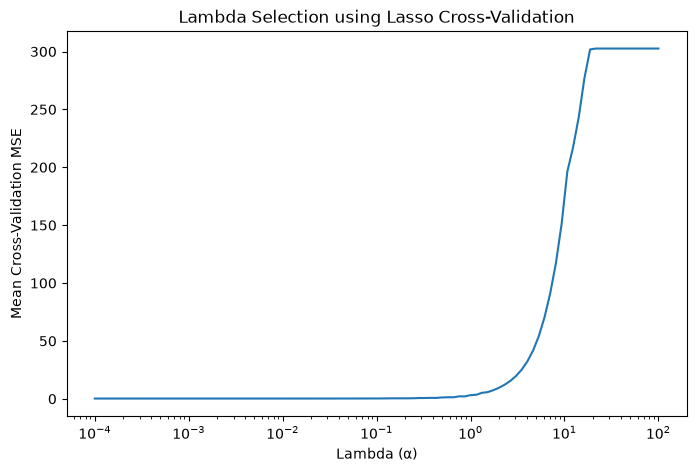

In [32]:
import matplotlib.pyplot as plt

lasso_cv_model = lasso_cv.named_steps["lassocv"]

plt.figure(figsize=(8, 5))
plt.plot(
    lasso_cv_model.alphas_,
    np.mean(lasso_cv_model.mse_path_, axis=1)
)

plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Lambda Selection using Lasso Cross-Validation")
plt.show()